# 🌊 Oil Spill Classification

This notebook is designed to help you practice classification modeling using a dataset that involves detecting oil spills based on satellite data.


In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/oil-spill.csv')
df.head()

,1,2558,1506.09,456.63,90,6395000,40.88,7.89,29780,0.19,...,2850,1000,763.16,135.46,3.73,0.6,33243.19,65.74,7.95,1.1
0,2,22325,79.11,841.03,180,55812500.0,51.11,1.21,61900.0,0.02,...,5750.00,11500.00,9593.48,1648.80,0.60,0,51572.04,65.73,6.26,0
1,3,115,1449.85,608.43,88,287500.0,40.42,7.34,3340.0,0.18,...,1400.00,250.00,150.00,45.13,9.33,1,31692.84,65.81,7.84,1
2,4,1201,1562.53,295.65,66,3002500.0,42.40,7.97,18030.0,0.19,...,6041.52,761.58,453.21,144.97,13.33,1,37696.21,65.67,8.07,1
3,5,312,950.27,440.86,37,780000.0,41.43,7.03,3350.0,0.17,...,1320.04,710.63,512.54,109.16,2.58,0,29038.17,65.66,7.35,0
4,6,54,1438.13,544.91,82,135000.0,44.67,6.92,1570.0,0.15,...,608.28,200.00,150.00,52.22,4.06,0,30967.25,65.77,7.85,1


In [2]:
# Create column names: f0, f1, ..., f(n-2), class
num_cols = df.shape[1]

columns = [f"f{i}" for i in range(num_cols - 1)] + ["class"]
df.columns = columns

df.head()


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f40,f41,f42,f43,f44,f45,f46,f47,f48,class
0,2,22325,79.11,841.03,180,55812500.0,51.11,1.21,61900.0,0.02,...,5750.00,11500.00,9593.48,1648.80,0.60,0,51572.04,65.73,6.26,0
1,3,115,1449.85,608.43,88,287500.0,40.42,7.34,3340.0,0.18,...,1400.00,250.00,150.00,45.13,9.33,1,31692.84,65.81,7.84,1
2,4,1201,1562.53,295.65,66,3002500.0,42.40,7.97,18030.0,0.19,...,6041.52,761.58,453.21,144.97,13.33,1,37696.21,65.67,8.07,1
3,5,312,950.27,440.86,37,780000.0,41.43,7.03,3350.0,0.17,...,1320.04,710.63,512.54,109.16,2.58,0,29038.17,65.66,7.35,0
4,6,54,1438.13,544.91,82,135000.0,44.67,6.92,1570.0,0.15,...,608.28,200.00,150.00,52.22,4.06,0,30967.25,65.77,7.85,1


## 🔍 2. Dataset Overview

In [3]:
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 936 entries, 0 to 935
Data columns (total 50 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f0      936 non-null    int64  
 1   f1      936 non-null    int64  
 2   f2      936 non-null    float64
 3   f3      936 non-null    float64
 4   f4      936 non-null    int64  
 5   f5      936 non-null    float64
 6   f6      936 non-null    float64
 7   f7      936 non-null    float64
 8   f8      936 non-null    float64
 9   f9      936 non-null    float64
 10  f10     936 non-null    float64
 11  f11     936 non-null    float64
 12  f12     936 non-null    float64
 13  f13     936 non-null    float64
 14  f14     936 non-null    float64
 15  f15     936 non-null    float64
 16  f16     936 non-null    float64
 17  f17     936 non-null    float64
 18  f18     936 non-null    float64
 19  f19     936 non-null    float64
 20  f20     936 non-null    float64
 21  f21     936 non-null    float64
 22  f2

,0
f0,0
f1,0
f2,0
f3,0
f4,0
f5,0
f6,0
f7,0
f8,0
f9,0


## 📊 3. Exploratory Data Analysis (EDA)

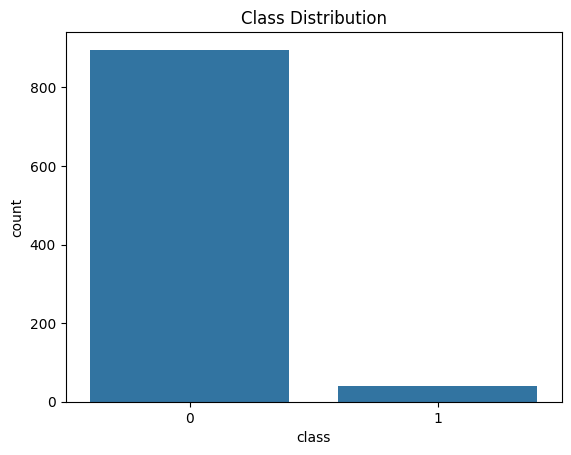

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Distribution of classes
sns.countplot(data=df, x='class')  # Replace 'class' with the actual target column
plt.title("Class Distribution")
plt.show()




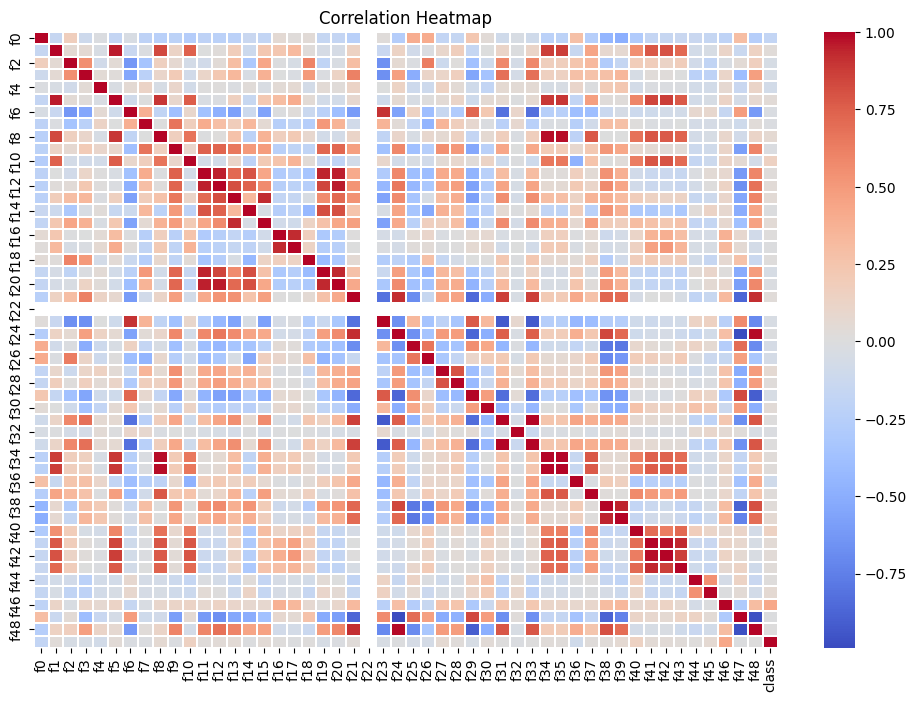

In [5]:
# Correlation heatmap
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', linewidths=0.3)
plt.title("Correlation Heatmap")
plt.show()


## 🧼 4. Data Preprocessing

In [6]:
# Handle missing values if any
df.fillna(df.median(numeric_only=True), inplace=True)



In [7]:
# Encode categorical features (if any)
df = pd.get_dummies(df, drop_first=True)



In [8]:
# Feature selection / dimensionality reduction (optional)
# Remove constant columns (zero variance)
df = df.loc[:, df.nunique() > 1]

## ✂️ 5. Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('class', axis=1)  # Replace with your actual target column
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 🧠 6. Model Training (Random Forest Classifier)

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

## 📏 7. Model Evaluation

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9521276595744681
[[179   0]
 [  9   0]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       179
           1       0.00      0.00      0.00         9

    accuracy                           0.95       188
   macro avg       0.48      0.50      0.49       188
weighted avg       0.91      0.95      0.93       188



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 📚 8. Student Exercises
Try Logistic Regression, SVM, or Gradient Boosting instead.

Visualize feature importance using model.feature_importances_.

Use PCA or t-SNE for visualization.

Plot confusion matrix using sns.heatmap.

Tune the Random Forest hyperparameters using GridSearchCV.

In [12]:
#Try Logistic Regression, SVM, or Gradient Boosting instead.
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 0.9521276595744681
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       179
           1       0.50      0.22      0.31         9

    accuracy                           0.95       188
   macro avg       0.73      0.61      0.64       188
weighted avg       0.94      0.95      0.94       188



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
#svm
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))


SVM Accuracy: 0.9521276595744681


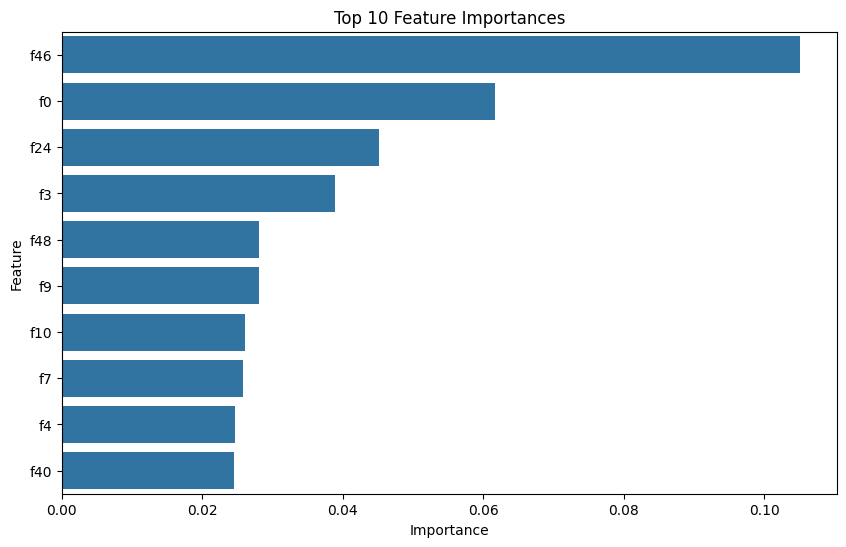

In [14]:
#Visualize feature importance using model.feature_importances_.
importances = model.feature_importances_
feature_names = X.columns

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_imp_df.head(10), x='Importance', y='Feature')
plt.title("Top 10 Feature Importances")
plt.show()


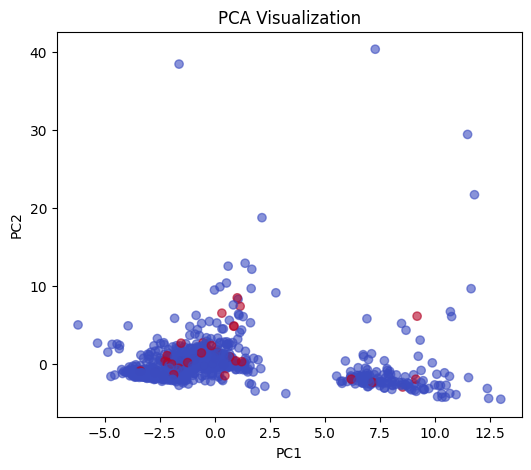

In [15]:
#Use PCA or t-SNE for visualization.
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.6)
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


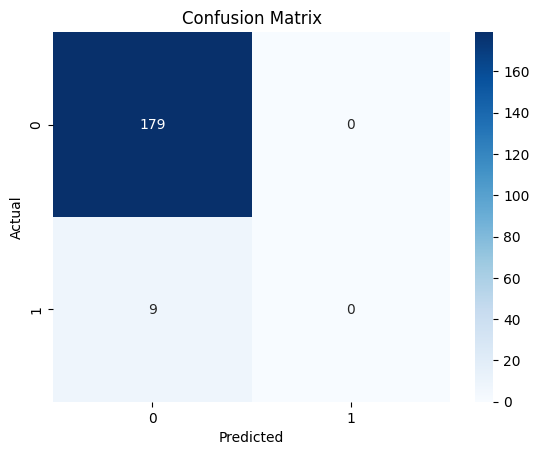

In [16]:
#Plot confusion matrix using sns.heatmap.
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
#Tune the Random Forest hyperparameters using GridSearchCV.
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Accuracy: 0.9652369477911646
